# Expand MNIST Dataset

In [85]:
import numpy as np 
import matplotlib.pyplot as plt 
from xgboost import XGBClassifier
from sklearn.datasets import fetch_openml
from sklearn.metrics import precision_recall_curve, precision_score, recall_score, f1_score, accuracy_score, roc_auc_score, ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_score, cross_val_predict
import joblib

In [37]:
mnist = fetch_openml("mnist_784", as_frame=False)
xTrain, yTrain, xTest, yTest = mnist.data[:60000], mnist.target[:60000].astype(np.int8), mnist.data[60000:], mnist.target[60000:].astype(np.int8)
xTrain, yTrain, xTest, yTest

(array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], shape=(60000, 784)),
 array([5, 0, 4, ..., 5, 6, 8], shape=(60000,), dtype=int8),
 array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], shape=(10000, 784)),
 array([7, 2, 1, ..., 4, 5, 6], shape=(10000,), dtype=int8))

In [88]:
def displayImage(imgArr):
    imgArr = imgArr.reshape(28,28)
    plt.imshow(imgArr, cmap="binary")
    plt.axis("off")
    plt.show()
def genRandomIndex(highBound):
    return np.random.randint(low=0, high=highBound, dtype=int)

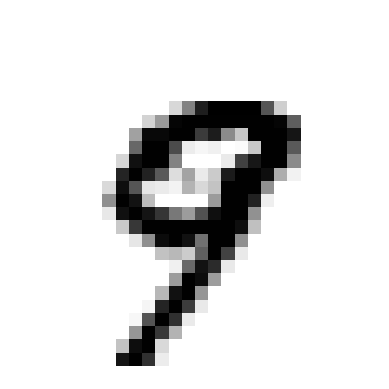

In [39]:
displayImage(xTrain[87])

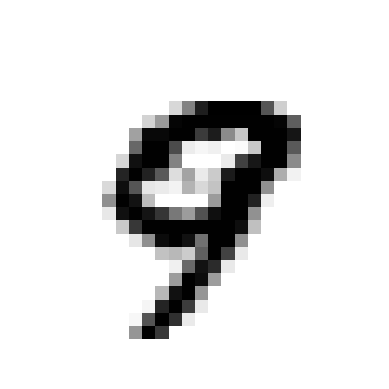

In [40]:
alterCrop = xTrain[87].copy()
alterCrop = np.append(alterCrop, np.zeros(100))
alterCrop = np.delete(alterCrop, np.arange(684, 784, 1))
displayImage((alterCrop))


In [41]:
np.zeros(28)

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [42]:
arr = np.arange(0, 784)
arr.reshape(28, 28)

array([[  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
         13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
         26,  27],
       [ 28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,  40,
         41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,  53,
         54,  55],
       [ 56,  57,  58,  59,  60,  61,  62,  63,  64,  65,  66,  67,  68,
         69,  70,  71,  72,  73,  74,  75,  76,  77,  78,  79,  80,  81,
         82,  83],
       [ 84,  85,  86,  87,  88,  89,  90,  91,  92,  93,  94,  95,  96,
         97,  98,  99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109,
        110, 111],
       [112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124,
        125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137,
        138, 139],
       [140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152,
        153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165,
        166, 167],
       [16

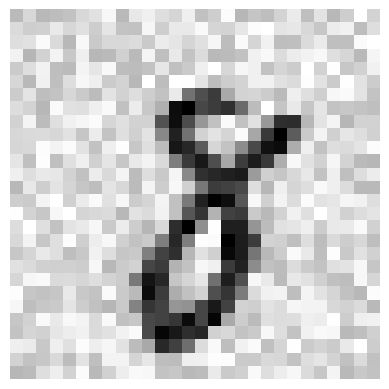

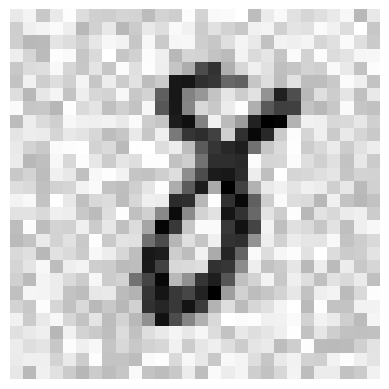

In [43]:
alterDown = xTrain[784].copy()
alterDown = np.concatenate((np.zeros(56), alterDown))
alterDown = np.delete(alterDown, np.arange(728, 784))
displayImage(alterDown + np.random.randint(0, 100, alterDown.shape))
displayImage(xTrain[784]+ np.random.randint(0, 100, alterDown.shape))

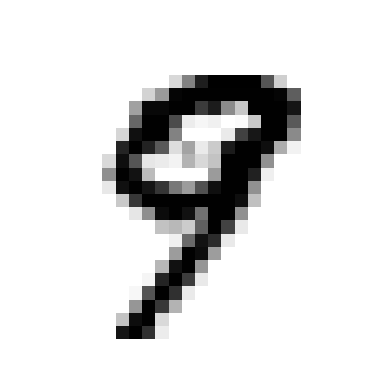

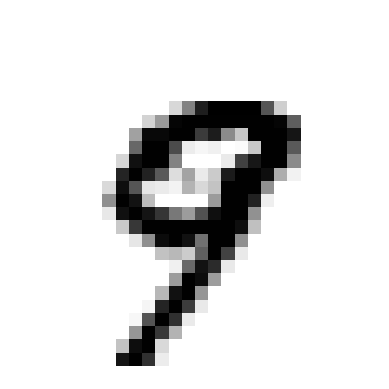

In [44]:
alterUp= xTrain[87].copy()
alterUp = np.concatenate((alterUp, np.zeros(56)))
alterUp = np.delete(alterUp, np.arange(0, 56))
displayImage(alterUp)
displayImage(xTrain[87])

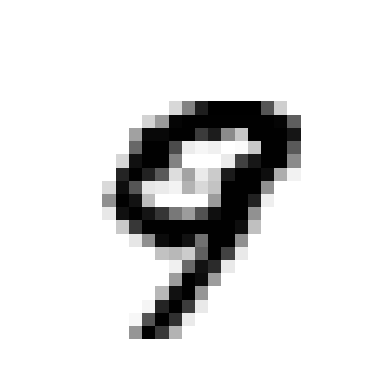

In [73]:
x = np.concatenate((xTrain, np.zeros((xTrain.shape[0], 84))), axis=1)
alterUnderCrop = np.delete(x, np.s_[700:784], axis=1)
displayImage(alterUnderCrop[87])

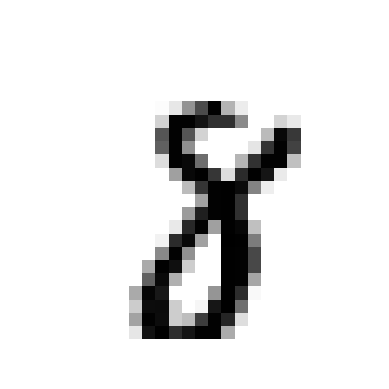

In [46]:
x = np.concatenate((np.zeros((xTrain.shape[0], 84)), xTrain), axis=1)
alterDownword = np.delete(x, np.s_[700:784], axis=1)
displayImage(alterDownword[784])

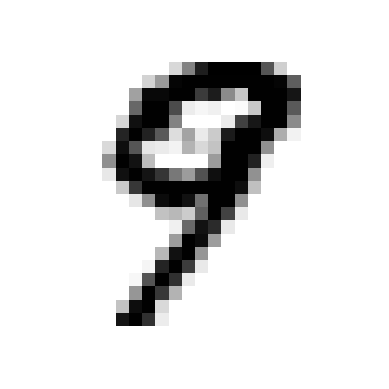

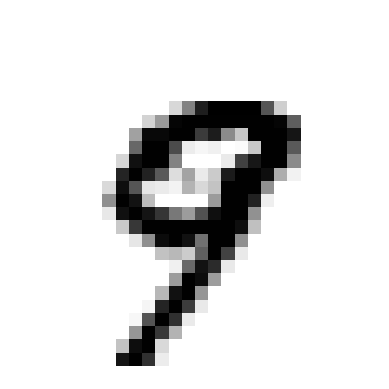

In [47]:
x = np.concatenate((xTrain, np.zeros((xTrain.shape[0], 84))), axis=1)
alterUpword = np.delete(x, np.s_[0:84], axis=1)
displayImage(alterUpword[87])
displayImage(xTrain[87])

In [48]:
arr = np.arange(0, 784).reshape(28, 28)

arr = np.concatenate((arr,arr), axis=0)

arr.shape

(56, 28)

In [74]:
xTrainExtended = np.concatenate((xTrain, alterUnderCrop, alterDownword, alterUpword), axis=0)
yTrainExtended = np.concatenate((yTrain, yTrain, yTrain, yTrain), axis=0)
print(xTrain.shape)
print(xTrainExtended.shape)
print(yTrain.shape)
yTrainExtended.shape

(60000, 784)
(240000, 784)
(60000,)


(240000,)

# Before

In [50]:
primaryModel = XGBClassifier(
    tree_method="hist",n_jobs=-1,
    eval_metric="mlogloss")
oGDSPredict = cross_val_predict(primaryModel, xTrain, yTrain, cv=5, n_jobs=-1)
oGDSPredict

array([5, 0, 4, ..., 5, 6, 8], shape=(60000,))

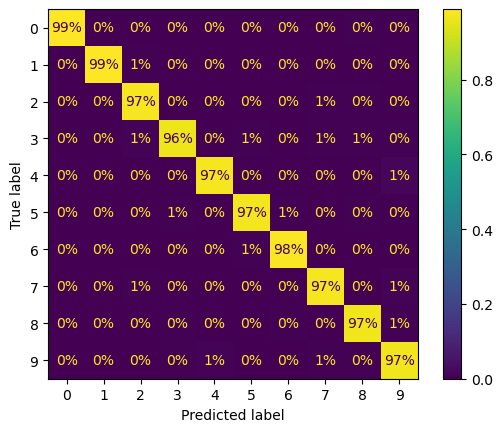

In [51]:
ConfusionMatrixDisplay.from_predictions(yTrain, oGDSPredict, normalize="true", values_format=".0%")

# After

In [52]:
primaryModel = XGBClassifier(
    tree_method="hist",n_jobs=-1,
    eval_metric="mlogloss")
extendentDataPredict = cross_val_predict(primaryModel, xTrainExtended, yTrainExtended, cv=5, n_jobs=-1)
extendentDataPredict

array([5, 0, 4, ..., 5, 6, 8], shape=(240000,))

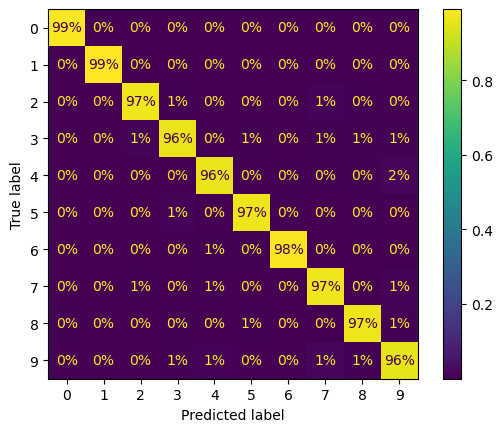

In [53]:
ConfusionMatrixDisplay.from_predictions(yTrainExtended, extendentDataPredict, normalize="true", values_format=".0%")

In [54]:
oGModel = XGBClassifier(
    tree_method="hist",n_jobs=-1,
    eval_metric="mlogloss")
eDModel = XGBClassifier(
    tree_method="hist",n_jobs=-1,
    eval_metric="mlogloss")

In [57]:
oGModel.fit(xTrain, yTrain)

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'mlogloss'


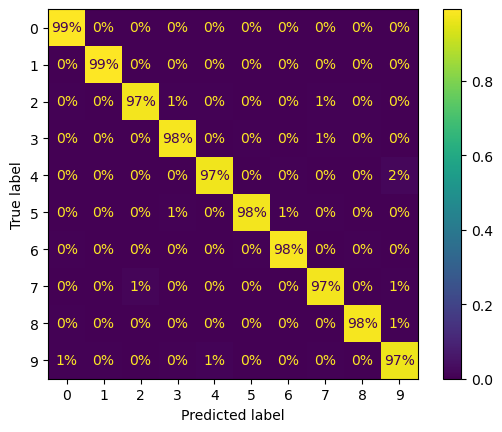

In [58]:
oGP = oGModel.predict(xTest)
ConfusionMatrixDisplay.from_predictions(yTest, oGP, normalize="true", values_format=".0%")

In [61]:
accuracy_score(yTest, oGP)

0.9784

In [75]:
eDModel.fit(xTrainExtended, yTrainExtended)

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'mlogloss'


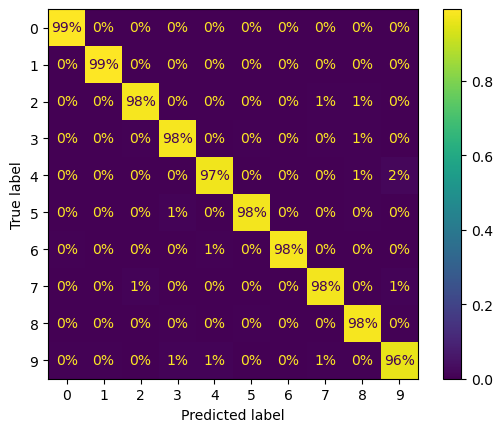

In [76]:
eDP = eDModel.predict(xTest)
ConfusionMatrixDisplay.from_predictions(yTest, eDP, normalize="true", values_format=".0%")

In [77]:
accuracy_score(yTest, eDP)

0.9785

In [81]:
xGBCHeavyModel = XGBClassifier(
    tree_method="hist",
    n_jobs=11,
    eval_metric="mlogloss",
    random_state=67,
    learning_rate = 0.03,
    n_estimators= 1600,
    )

In [82]:
xGBCHeavyModel.fit(xTrainExtended, yTrainExtended)

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'mlogloss'


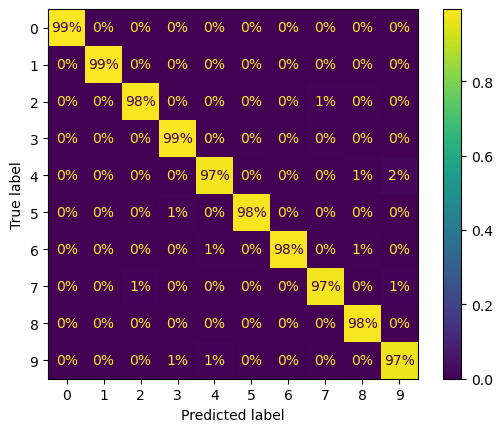

'98.13%'

In [86]:
finalPredict = xGBCHeavyModel.predict(xTest)
ConfusionMatrixDisplay.from_predictions(yTest, finalPredict, normalize="true", values_format=".0%")
plt.show()
f"{accuracy_score(yTest, finalPredict)*100}%"

In [87]:
joblib.dump(xGBCHeavyModel, "mnist_number_classifier.pkl")

['mnist_number_classifier.pkl']

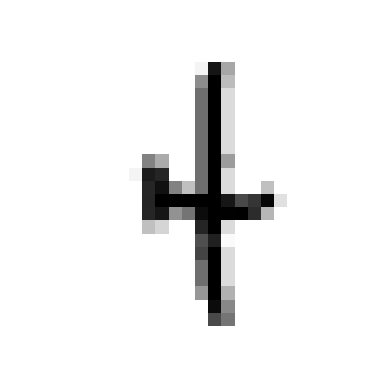

Fact: 4
AI: 4


In [136]:
randomIndex = genRandomIndex(highBound=10000)
displayImage(xTest[randomIndex])
print(f"Fact: {yTest[randomIndex]}")
print(f"AI: {(xGBCHeavyModel.predict([xTest[randomIndex]]))[0]}")